In [9]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import MaxPooling2D,Flatten,Convolution2D
from keras import Sequential


In [10]:
from pathlib import Path

base_dir = Path.cwd()
if not (base_dir / "TRAIN").exists() or not (base_dir / "TEST").exists():
    base_dir = Path(r"d:/Users/Downloads/TIME_PASS")

TRAIN_DIR = str(base_dir / "TRAIN")
TEST_DIR = str(base_dir / "TEST")


In [20]:
import os
from PIL import Image




def remove_corrupted_images(directory):
    print(f"Scanning directory: {directory} for corrupted images...")
    bad_files = []
    
    # Walk through all subfolders (the 11 class folders)
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                # Pillow's verify() reads the file header to check integrity
                img = Image.open(file_path)
                img.verify() 
            except (IOError, SyntaxError):
                print(f"🚨 Corrupted file detected: {file_path}")
                bad_files.append(file_path)
                
    # Delete the corrupted files
    if not bad_files:
        print("✅ No corrupted images found. You are good to go!")
    else:
        for bad_file in bad_files:
            os.remove(bad_file)
            print(f"🗑️ Removed: {bad_file}")
        print(f"\nCleanup complete. Removed {len(bad_files)} bad images.")

# Run the cleaner
remove_corrupted_images(TEST_DIR)

Scanning directory: d:\Users\Downloads\TIME_PASS\TEST for corrupted images...
🚨 Corrupted file detected: d:\Users\Downloads\TIME_PASS\TEST\healthy\HL_(336).png
🗑️ Removed: d:\Users\Downloads\TIME_PASS\TEST\healthy\HL_(336).png

Cleanup complete. Removed 1 bad images.


In [21]:
from keras.src.random import shuffle
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dataset=tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="training",
    seed=23,
    image_size = IMG_SIZE,
    batch_size=BATCH_SIZE,


)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split = 0.15,
    subset = "validation",
    seed = 23,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,

)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False

)
class_names = train_dataset.class_names

Found 25838 files belonging to 11 classes.
Using 21963 files for training.
Found 25838 files belonging to 11 classes.
Using 3875 files for validation.
Found 6679 files belonging to 11 classes.


In [22]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def normalize_dataset(dataset) :
  return dataset.map(lambda x,y : (preprocess_input(x) , y))

train_dataset = normalize_dataset(train_dataset)
test_dataset = normalize_dataset(test_dataset)

In [13]:
class RandomBrightness(tf.keras.layers.Layer):
    def call(self, images, training=None):
        if training:
            images = tf.image.random_brightness(images, max_delta=0.2)
        return images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.2,0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
    tf.keras.layers.GaussianNoise(0.05),
    tf.keras.layers.RandomContrast(0.2),
    RandomBrightness()
],name = "data_augmentation")

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense ,Dropout,GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam

input_shape = (224,224,3)

base_model = EfficientNetB0(weights='imagenet' , include_top=False,input_shape=input_shape)

base_model.trainable=False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(class_names),activation='softmax')
])

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,358 (16.71 MB)

 Trainable params: 331,275 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint,ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

check_point = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1

)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stop,check_point,reduce_lr]

EPOCHS = 100

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)



Epoch 1/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6542 - loss: 1.1284
Epoch 1: val_loss improved from None to 0.40982, saving model to best_model.h5


Epoch 1/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6542 - loss: 1.1284
Epoch 1: val_loss improved from None to 0.40982, saving model to best_model.h5


Epoch 1/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6542 - loss: 1.1284
Epoch 1: val_loss improved from None to 0.40982, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 541s 776ms/step - accuracy: 0.7517 - loss: 0.7814 - val_accuracy: 0.8679 - val_loss: 0.4098 - learning_rate: 0.0010
Epoch 2/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.8360 - loss: 0.4925
Epoch 2: val_loss improved from 0.40982 to 0.33176, saving model to best_model.h5


Epoch 1/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6542 - loss: 1.1284
Epoch 1: val_loss improved from None to 0.40982, saving model to best_model.h5


...


Epoch 28: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 402s 585ms/step - accuracy: 0.9671 - loss: 0.0999 - val_accuracy: 0.9665 - val_loss: 0.1145 - learning_rate: 4.0000e-05
Epoch 29/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9670 - loss: 0.0996
Epoch 29: val_loss improved from 0.11451 to 0.11408, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 399s 581ms/step - accuracy: 0.9672 - loss: 0.0987 - val_accuracy: 0.9667 - val_loss: 0.1141 - learning_rate: 4.0000e-05
Epoch 30/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9654 - loss: 0.0962
Epoch 30: val_loss improved from 0.11408 to 0.11353, saving model to best_model.h5



Epoch 30: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 406s 591ms/step - accuracy: 0.9665 - loss: 0.0959 - val_accuracy: 0.9667 - val_loss: 0.1135 - learning_rate: 4.0000e-05
Epoch 31/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.9681 - loss: 0.0968
Epoch 31: val_loss improved from 0.11353 to 0.11304, saving model to best_model.h5



Epoch 31: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 402s 585ms/step - accuracy: 0.9685 - loss: 0.0958 - val_accuracy: 0.9659 - val_loss: 0.1130 - learning_rate: 4.0000e-05
Epoch 32/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.9638 - loss: 0.1021
Epoch 32: val_loss improved from 0.11304 to 0.11212, saving model to best_model.h5



Epoch 32: finished saving model to best_model.h5
687/687 ━━━━━━━━━━━━━━━━━━━━ 497s 724ms/step - accuracy: 0.9664 - loss: 0.0967 - val_accuracy: 0.9659 - val_loss: 0.1121 - learning_rate: 4.0000e-05
Epoch 33/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9646 - loss: 0.1025
Epoch 33: val_loss did not improve from 0.11212
687/687 ━━━━━━━━━━━━━━━━━━━━ 552s 803ms/step - accuracy: 0.9671 - loss: 0.0987 - val_accuracy: 0.9662 - val_loss: 0.1124 - learning_rate: 4.0000e-05
Epoch 34/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.9692 - loss: 0.0924
Epoch 34: val_loss did not improve from 0.11212
687/687 ━━━━━━━━━━━━━━━━━━━━ 562s 803ms/step - accuracy: 0.9689 - loss: 0.0928 - val_accuracy: 0.9662 - val_loss: 0.1126 - learning_rate: 4.0000e-05
Epoch 35/100
687/687 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.9708 - loss: 0.0889
Epoch 35: val_loss did not improve from 0.11212

Epoch 35: ReduceLROnPlateau reducing learning rate to 1e-05.
687/687 ━━━━━━━━━━━━━━━━━━━

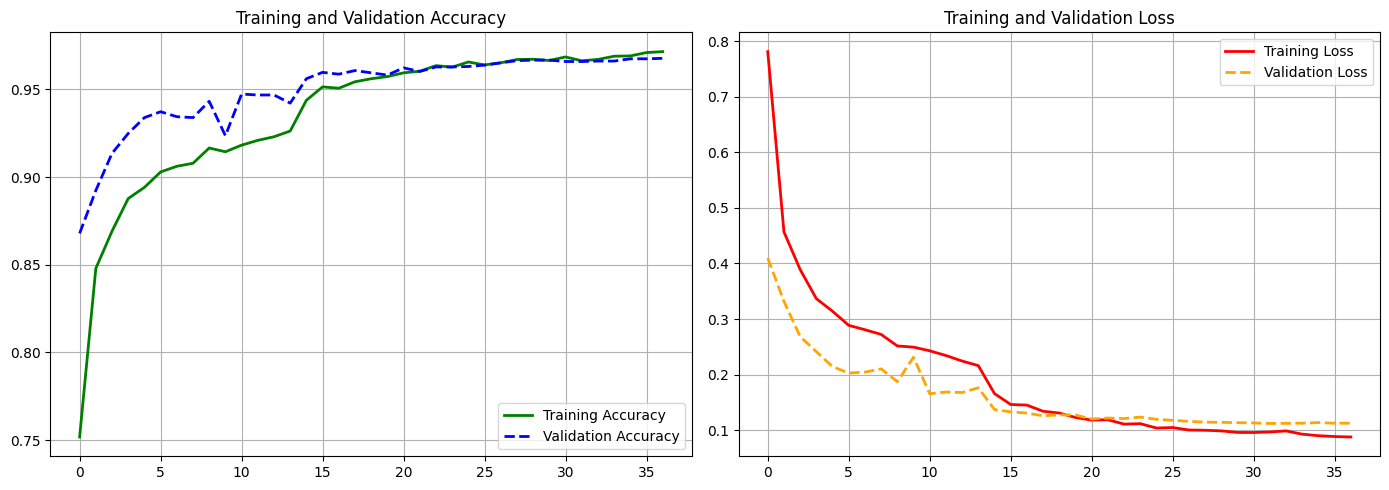

In [23]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# Create a figure for the plots
plt.figure(figsize=(14, 5))


# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='green', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='blue', linewidth=2, linestyle='--')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
print("Evaluating the model on the unseen test dataset...")
test_loss,test_accuracy = model.evaluate(test_dataset,verbose=1) 
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Evaluating the model on the unseen test dataset...
209/209 ━━━━━━━━━━━━━━━━━━━━ 200s 957ms/step - accuracy: 0.9641 - loss: 0.1310
Test Accuracy: 96.41%
Test Loss: 0.1310


Extracting true labels...
Generating predictions on the test dataset...
209/209 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step
Classification Report..
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.98      0.96      0.97       728
                        Early_blight       0.95      0.93      0.94       643
                         Late_blight       0.96      0.96      0.96       792
                           Leaf_Mold       0.97      0.98      0.97       739
                  Septoria_leaf_spot       0.94      0.94      0.94       746
Spider_mites Two-spotted_spider_mite       0.95      0.97      0.96       435
                         Target_Spot       0.93      0.93      0.93       457
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.99      0.99       498
                 Tomato_mosaic_virus       0.99      0.97      0.98       584
                             healthy       0.98      0.99      0.98       805
   

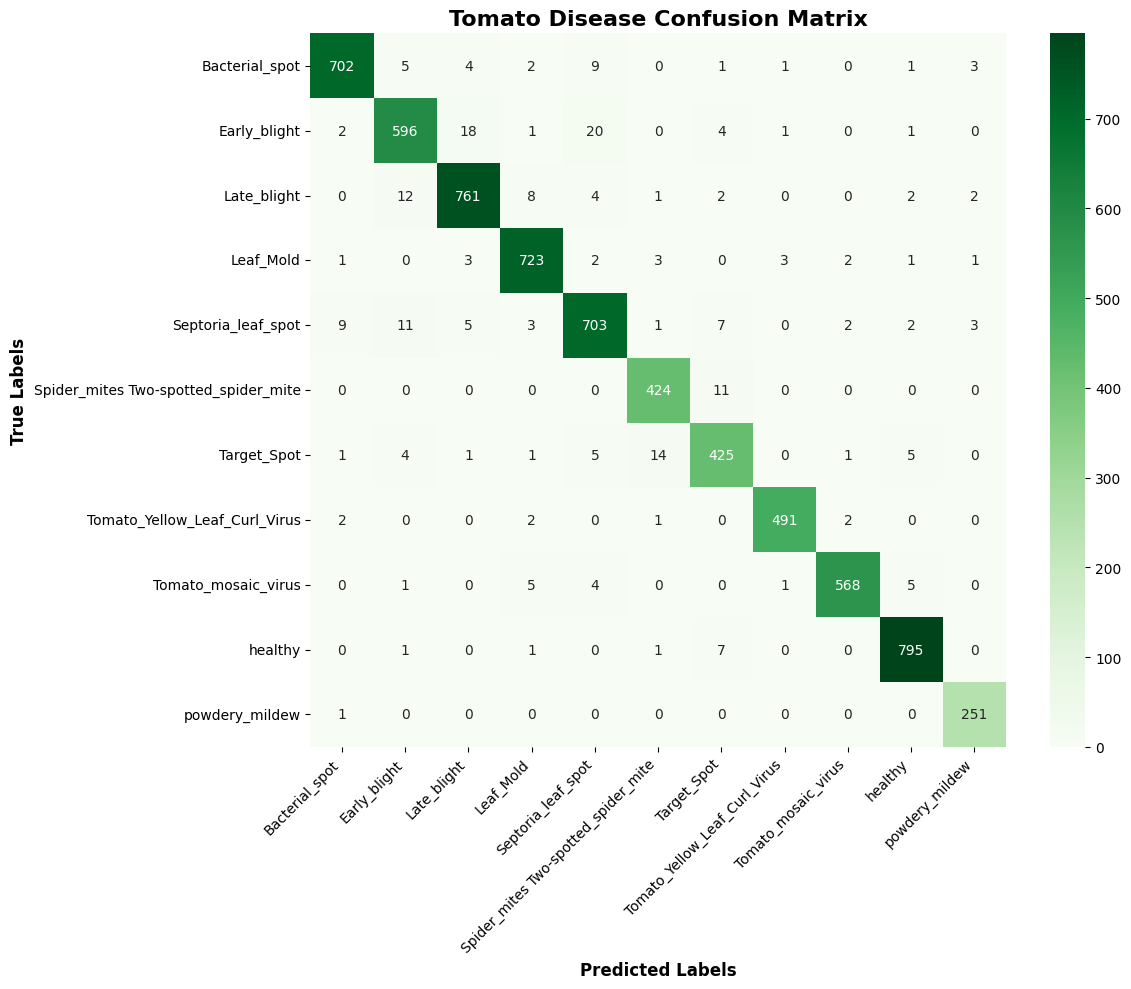

In [25]:
from sklearn.metrics import classification_report,confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Extracting true labels...")
y_true = np.concatenate([y for x ,y in test_dataset] , axis = 0)

print("Generating predictions on the test dataset...")
y_pred_probs= model.predict(test_dataset,verbose=1)
y_pred = np.argmax(y_pred_probs,axis=1)

print("Classification Report..")
print(classification_report(y_true,y_pred,target_names=class_names))


cm = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.title('Tomato Disease Confusion Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

--- Top 3 Predictions ---
Tomato_mosaic_virus...... 37.5%
Bacterial_spot........... 30.8%
Late_blight.............. 14.5%
-------------------------



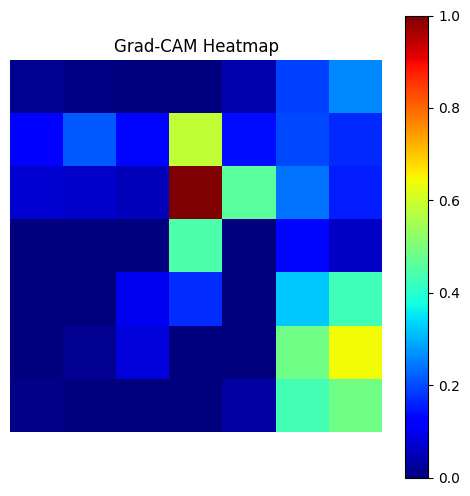

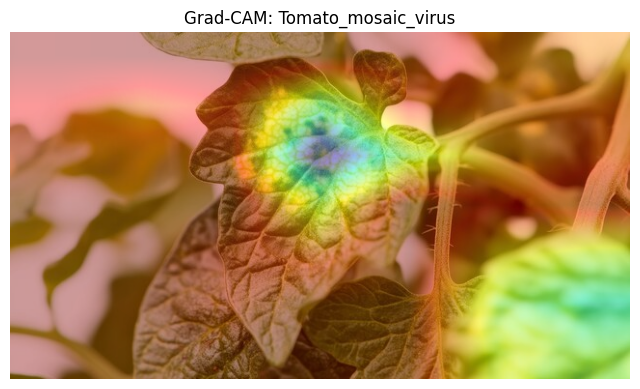

In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

IMG_SIZE = (224, 224)

# -----------------------------
# Load Image
# -----------------------------
image_path = r"D:\Users\Downloads\TIME_PASS\image.png"

img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)

img_array = tf.keras.utils.img_to_array(img)

img_batch = np.expand_dims(img_array, axis=0)

img_batch = tf.keras.applications.efficientnet.preprocess_input(img_batch)

# -----------------------------
# Prediction (Updated for Top 3)
# -----------------------------
predictions = model.predict(img_batch)

# Get the indices of the top 3 predictions, sorted in descending order
top_3_indices = np.argsort(predictions[0])[-3:][::-1]

# Set the primary predicted class for the Grad-CAM downstream task
predicted_class = top_3_indices[0]

print("\n--- Top 3 Predictions ---")
for i in top_3_indices:
    disease_name = class_names[i]
    confidence = predictions[0][i] * 100
    # The :.<25 formats the string to be left-aligned, padded with dots up to 25 characters
    print(f"{disease_name:.<25} {confidence:.1f}%")
print("-------------------------\n")


# -----------------------------
# Build Model (if needed)
# -----------------------------
_ = model(tf.zeros((1, 224, 224, 3)))

# -----------------------------
# Base EfficientNet & Nested Model Fix
# -----------------------------
# 1. Target the base model
base_model = model.layers[0]
last_conv_layer = base_model.get_layer("top_conv")

# 2. Map ONLY the base model's inputs to its conv layer and its final output
base_grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

# -----------------------------
# Compute Gradients
# -----------------------------
with tf.GradientTape() as tape:
    # 3. Get the feature maps and the base model's output
    conv_outputs, base_output = base_grad_model(img_batch)
    
    # 4. Pass the base output through your custom top layers manually
    x = base_output
    for layer in model.layers[1:]:
        # Set training=False so Dropout and BatchNorm behave like they are in inference mode
        x = layer(x, training=False) 
        
    final_predictions = x
    loss = final_predictions[:, predicted_class]

# Compute gradients of the loss with respect to the conv_outputs
grads = tape.gradient(loss, conv_outputs)

# -----------------------------
# Importance of each channel
# -----------------------------
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

# Apply ReLU to keep only features that have a positive influence
heatmap = tf.maximum(heatmap, 0)

# FIX: Add a tiny epsilon (1e-10) to prevent a division by zero error if max is 0
heatmap /= (tf.reduce_max(heatmap) + 1e-10)
heatmap = heatmap.numpy()

# -----------------------------
# Show Heatmap
# -----------------------------
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

# -----------------------------
# Overlay on Original Image
# -----------------------------
original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

heatmap = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Blend original image and heatmap
overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title(f"Grad-CAM: {class_names[predicted_class]}")
plt.axis("off")
plt.show()